In [7]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [3]:
#Helper function to cleanly display images in Jupyter Notebook
def show_digit(image,title='Handwritten Digit',cmap='gray'):
    plt.figure(figsize=(3,3))
    plt.imshow(image,cmap=cmap)
    plt.title(title,fontsize=11,fontweight='bold')
    plt.axis('off')
    plt.show()

def show_digit_grid(images,labels,cols=5,figsize=(12,3)):
    fig,axes=plt.subplots(1,cols,figsize=figsize)
    for i in range(cols):
        axes[i].imshow(images[i],cmap='gray')
        axes[i].set_title(f"Label: {labels[i]}",fontsize=10,fontweight='bold')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

Total Handwritten Images in Dataset: 1797
Single Image Shape: (8, 8) (8 rows by 8 columns)


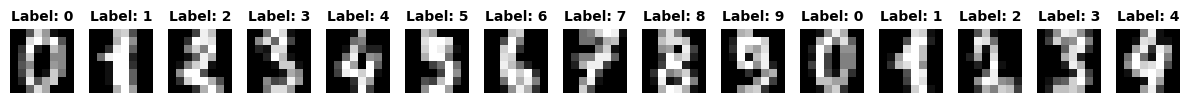

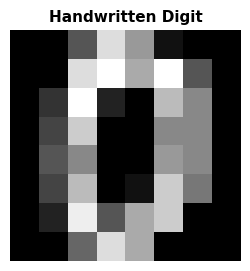

In [4]:
#Load the Handwritten Digits Dataset
digits=load_digits()

x_raw=digits.images #8x8 pixel images (features)
y_raw=digits.target # True numeriacal labels (0 to 9) (target)

print(f"Total Handwritten Images in Dataset: {len(x_raw)}")
print(f"Single Image Shape: {x_raw[0].shape} (8 rows by 8 columns)")

#Show the first 5 handwritten digits in the dataset
show_digit_grid(x_raw[:15],y_raw[:15],cols=15)
show_digit(x_raw[0])

In [5]:
#Inspecting pixel numbers of digit '0'
sample_digit=x_raw[0]
print("--- Pixel Matrix of Handwritten Digit '0' ---")
print(sample_digit.astype(int))

print(f"Min Pixel Instensity (Background): {sample_digit.min()}")
print(f"Max Pixel Intensity (Ink): {sample_digit.max()}")

--- Pixel Matrix of Handwritten Digit '0' ---
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]
Min Pixel Instensity (Background): 0.0
Max Pixel Intensity (Ink): 15.0


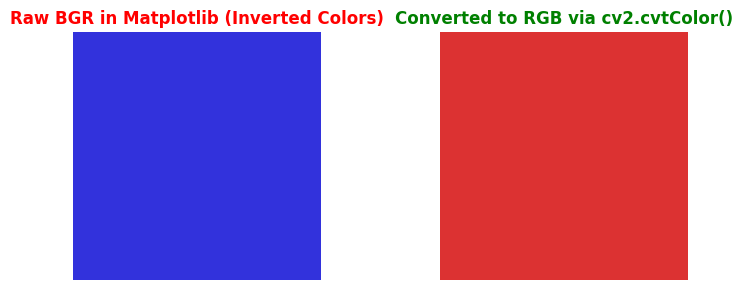

In [7]:
#OpenCV reads color images in BGR order but matplolib displays as RGB
#Creating a 3-channel color version of a digit to demonstrate BGR vs RGB
color_digit=cv2.cvtColor((sample_digit*15).astype(np.uint8),cv2.COLOR_GRAY2BGR)

#Apply a custom color tint (Red Ink)
color_digit[:,:,0]=50 #Blue channel
color_digit[:,:,1]=50 #Green channel
color_digit[:,:,2]=220 #Red channel

#Convert to RGB
rgb_digit=cv2.cvtColor(color_digit,cv2.COLOR_BGR2RGB)

fig,axes=plt.subplots(1,2,figsize=(8,3))
axes[0].imshow(color_digit)
axes[0].set_title("Raw BGR in Matplotlib (Inverted Colors)",color='red',fontweight='bold')
axes[0].axis('off')

axes[1].imshow(rgb_digit)
axes[1].set_title("Converted to RGB via cv2.cvtColor()",color='green',fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Original Shape: (8, 8)
Resized Shape: (32, 32)


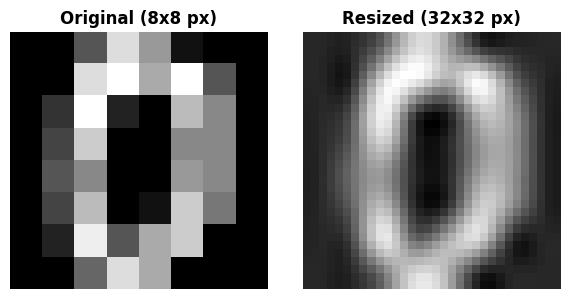

In [10]:
#Resizing an 8x8 digit image to 32x32 for better readability
digit_small=x_raw[0]
digit_resized=cv2.resize(digit_small,(32,32),interpolation=cv2.INTER_CUBIC)

print(f"Original Shape: {digit_small.shape}")
print(f"Resized Shape: {digit_resized.shape}")

fig,axes=plt.subplots(1,2,figsize=(6,3))
axes[0].imshow(digit_small,cmap='gray')
axes[0].set_title("Original (8x8 px)",fontweight='bold')
axes[0].axis('off')

axes[1].imshow(digit_resized,cmap='gray')
axes[1].set_title("Resized (32x32 px)",fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

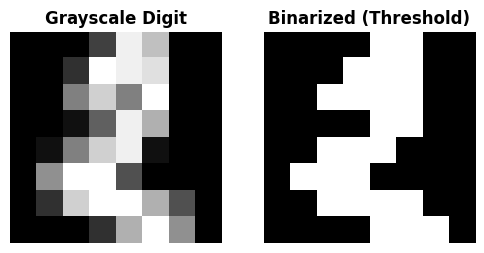

In [12]:
#Image Thresholding and Binarization
uint8_digit=(x_raw[2]*15).astype(np.uint8)

#Apply Simple Binary Thresholding (Cutoff at 100)
_,thresh_binary=cv2.threshold(uint8_digit,100,255,cv2.THRESH_BINARY)

fig,axes=plt.subplots(1,2,figsize=(6,3))
axes[0].imshow(uint8_digit,cmap='gray')
axes[0].set_title("Grayscale Digit",fontweight='bold')
axes[0].axis('off')

axes[1].imshow(thresh_binary,cmap='gray')
axes[1].set_title("Binarized (Threshold)",fontweight='bold')
axes[1].axis('off')

Total Contours Found: 1
Digit Bounding Box: x=1, y=0, width=6, height=8


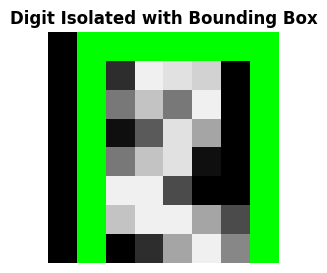

In [13]:
# Find contours(outline or boundary) around written number
contours, _=cv2.findContours(thresh_binary,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
print(f"Total Contours Found: {len(contours)}")

bbox_canvas=cv2.cvtColor(uint8_digit,cv2.COLOR_GRAY2BGR)

#Find bounding box for the digit
if len(contours)>0:
    cnt=max(contours,key=cv2.contourArea)
    x,y,w,h=cv2.boundingRect(cnt)

    #Draw a green bounding box around the digit
    cv2.rectangle(bbox_canvas,(x,y),(x+w,y+h),(0,255,0),1)
    print(f"Digit Bounding Box: x={x}, y={y}, width={w}, height={h}")

plt.figure(figsize=(3,3))
plt.imshow(cv2.cvtColor(bbox_canvas,cv2.COLOR_BGR2RGB))
plt.title("Digit Isolated with Bounding Box",fontweight='bold')
plt.axis('off')
plt.show()

In [ ]:
#Train a model

#Flatten the 8x8 2D images into 64-element 1D feature vectors for ML
x_features=x_raw.reshape(len(x_raw),-1)
y_labels=y_raw

#Split into 80% Training set and 20% Testing set
x_train,x_test,y_train,y_test=train_test_split(x_features,y_labels,test_size=0.2,random_state=42)

#Train KNN Model
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)

#Evalute accuracy
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)*100

print("[SUCCESS] Machine Learning Digit Classifier Trained Successfully")
print(f"Accuracy: {accuracy}")

[SUCCESS] Machine Learning Digit Classifier Trained Successfully
Accuracy: 98.33333333333333


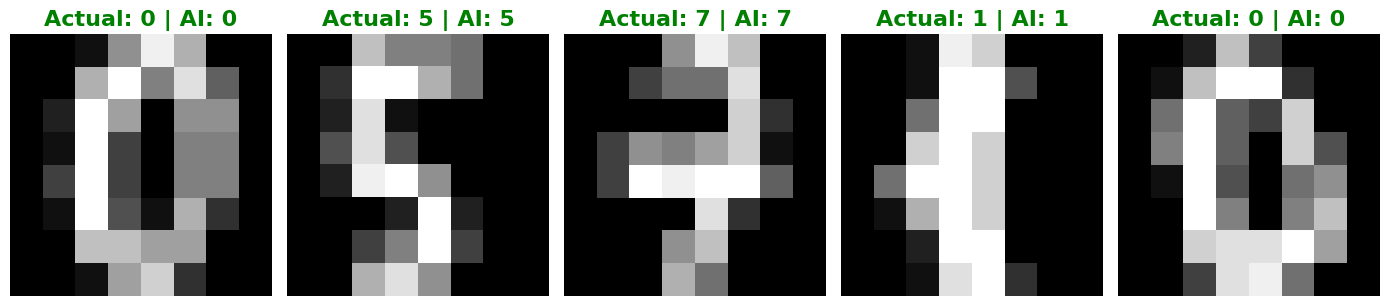

In [17]:
#End to End prediction pipeline
def predict_digit_from_image(raw_image):
    #1. OpenCV Preprocessing: Ensure image is 8x8 grayscale
    if len(raw_image.shape)==3:
        gray=cv2.cvtColor(raw_image,cv2.COLOR_BGR2GRAY)
    else:
        gray=raw_image.copy()
    gray_resized=cv2.resize(gray,(8,8),interpolation=cv2.INTER_AREA)

    #2. Prepare 1D feature vector for ML
    feature_vector=gray_resized.reshape(1,-1)

    #3. Model Prediction
    predicted_digit=model.predict(feature_vector)[0]

    return predicted_digit,gray_resized

#Test the pipeline on 5 random test samples
sample_indices=[10,25,43,99,150]
fig,axes=plt.subplots(1,5,figsize=(14,3))
for i,idx in enumerate(sample_indices):
    test_img=x_raw[idx]
    actual_label=y_raw[idx]

    #Run through OpenCV + ML Pipeline
    predicted_label,processed_img=predict_digit_from_image(test_img)
    
    axes[i].imshow(test_img,cmap='gray')
    axes[i].set_title(f"Actual: {actual_label} | AI: {predicted_label}",color='green' if actual_label==predicted_label else 'red',fontweight='bold',fontsize=16)
    axes[i].axis('off')

plt.tight_layout()
plt.show()